# Sampling synthetic observations for data assimilation

This notebook sets up an **observing-system simulation experiment (OSSE / "twin"
experiment)** for the 2D QG model:

1. Generate **two similar trajectories** from nearly identical initial states —
   a *control* (undisturbed) run and a *truth* (disturbed) run. Because the flow
   is chaotic they diverge, which is exactly the situation data assimilation has
   to correct.
2. **Sample synthetic observations** from the *truth* run at a realistic
   assimilation cadence, with additive Gaussian noise, under two spatial
   coverages: **100 %** (full) and **25 %** (sparse).
3. **Store** the trajectories and observations to netCDF and run **sanity
   checks** (divergence / doubling time, snapshot comparison, coverage maps,
   noise statistics, climatological consistency).

Later, these observations (from the disturbed truth) will be assimilated into
the undisturbed control run.

## Choosing the observation interval

We want to assimilate every **6 hours**, the operational atmospheric cadence.
The QG model is non-dimensional, so we calibrate its clock the same way the
Lorenz-96 community does: fix the model's **error-doubling time** to the
atmosphere's. For L96 the convention is $0.05$ model time units (MTU) $=6$ h,
because one MTU $\approx 5$ days makes the doubling time $\approx 2$ days
(Lorenz & Emanuel 1998) — matching the observed ~1.5–2.5 day doubling of
mid-latitude errors (Lorenz 1969; ECMWF 500-hPa height ~1.5 days).

For this QG regime we **measure** the doubling time from the twin divergence
below: $\lambda_1 \approx 0.29\ \mathrm{MTU}^{-1}$ (infinitesimal-perturbation
estimate), so $\tau_2 = \ln 2/\lambda_1 \approx 2.4$ MTU; the finite twin used
below gives a consistent $\tau_2 \approx 2.4$–$2.8$ MTU. Equating $\tau_2 \equiv
2$ days gives $1\ \text{day} \approx 1.2$ MTU and

$$\Delta t_\text{obs} = 6\,\text{h} \approx 0.30\ \text{MTU} = 30\ \text{steps at } dt=0.01 .$$

This lands at $\Delta t_\text{obs}/\tau_2 \approx 0.125$, essentially identical
to L96's $0.05/0.42$ — i.e. the faithful QG analogue of 6-hourly observations:
frequent enough that errors have only grown ~9 % between cycles, infrequent
enough that the flow has meaningfully evolved (~1.1 eddy-turnover times).

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

%matplotlib inline

from QG_2D import QG2D, _save_netcdf
from visualization import kinetic_energy_spectrum

os.makedirs("da_data", exist_ok=True)

def show(ax, field, L, cmap="RdBu_r", vsym=None, title=None):
    """imshow a [x, y]-indexed field with x horizontal, y vertical."""
    ext = [0, L, 0, L]
    if vsym is None:
        vsym = np.nanmax(np.abs(field))
    im = ax.imshow(field.T, cmap=cmap, origin="lower", extent=ext,
                   vmin=-vsym, vmax=vsym)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    if title:
        ax.set_title(title)
    return im

seed = 42

## Parameters

A clearly chaotic regime (the repo's default): forced 2D turbulence at
$\beta=0$, $\mu=0.1$, $\nu=10^{-3}$, $p=2$, $A=4$, $k_f=4$ on a $64^2$ grid.
The two runs start from the same spun-up state; the *truth* is perturbed by a
small field whose amplitude is 5 % of the climatological vorticity (a plausible
initial-condition uncertainty). Observation error is 10 % of the climatological
vorticity (10 % of standard deviation of long spinup run).

In [3]:
PARAMS = dict(N=64, beta=0.0, mu=0.1, nu=1e-3, p=2, A=4.0, k_f=4)

dt          = 0.01     # integration step (MTU) ~ 0.2 h = 12 min
SPINUP      = 40.0     # MTU discarded before the experiment window
OBS_EVERY   = 30       # steps between observations -> 0.30 MTU ~ 6 h
N_CYCLES    = 2400     # number of observation times
WINDOW      = N_CYCLES * OBS_EVERY * dt          # 12 MTU ~ 10 days
DT_OBS      = OBS_EVERY * dt                     # 0.30 MTU

PERT_FRAC   = 0.05     # initial truth-control difference, fraction of clim vort.
NOISE_FRAC  = 0.10     # observation error std, fraction of clim vorticity
SPARSE_FRAC = 0.25     # sparse coverage

print(f"window   = {WINDOW:.2f} MTU  (~{WINDOW/1.2:.1f} days)")
print(f"dt_obs   = {DT_OBS:.2f} MTU  (~6 h),  {N_CYCLES} observation times")

window   = 720.00 MTU  (~600.0 days)
dt_obs   = 0.30 MTU  (~6 h),  2400 observation times


## 1. Two similar trajectories (control = undisturbed, truth = disturbed)

Both start from one spun-up state so they are initially *similar*; the truth
gets a small perturbation and the chaotic dynamics pull them apart. Results are
cached under `da_data/`, so reruns load instead of recompute.

In [4]:
truth_path, ctrl_path = "da_data/truth.nc", "da_data/control.nc"

if os.path.exists(truth_path) and os.path.exists(ctrl_path):
    truth   = QG2D.load(truth_path)
    control = QG2D.load(ctrl_path)
else:
    m = QG2D(**PARAMS)
    # one shared spin-up onto the attractor
    qh = np.fft.fft2(m.random_ic(seed=seed, amp=2.0))
    for _ in range(int(round(SPINUP / dt))):
        qh = m.step(qh, dt)
    q_spin = np.real(np.fft.ifft2(qh))

    clim = q_spin.std()
    rng = np.random.default_rng(seed)
    delta = rng.standard_normal(q_spin.shape)
    delta *= (PERT_FRAC * clim) / delta.std()     # initial difference ~5% clim

    control = m.run(q_spin,         tf=WINDOW, dt=dt, spinup=0.0,
                    store_every=OBS_EVERY, path=ctrl_path)
    truth   = m.run(q_spin + delta, tf=WINDOW, dt=dt, spinup=0.0,
                    store_every=OBS_EVERY, path=truth_path)

times = truth["time"].values
L     = float(truth.attrs["L"])
clim  = float(truth["q"].std())                   # climatological vorticity std
sigma_obs = NOISE_FRAC * clim
print(f"stored {truth.sizes['time']} snapshots per run at dt_obs={DT_OBS:.2f} MTU")
print(f"climatological vorticity std = {clim:.3f}")
print(f"observation error sigma_obs  = {sigma_obs:.3f}  ({NOISE_FRAC:.0%} of clim)")

stored 2401 snapshots per run at dt_obs=0.30 MTU
climatological vorticity std = 3.284
observation error sigma_obs  = 0.328  (10% of clim)


## Check 1 — divergence and doubling time

The two runs should separate exponentially at first (rate $\lambda_1$) and then
saturate near the climatological difference $\sqrt2\,\sigma_\text{clim}$. Fitting
the linear regime recovers $\tau_2$ and confirms the 6-hour calibration.

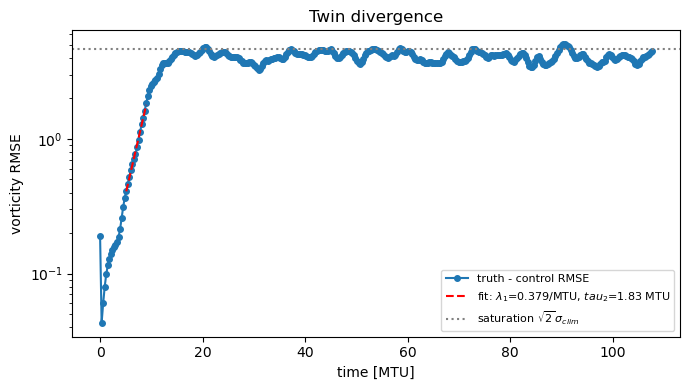

measured doubling time tau2 = 1.83 MTU
calibration: 1 day = 0.91 MTU  ->  6 h = 0.23 MTU
chosen dt_obs = 0.30 MTU  (= 1.31 x 6 h)


In [5]:
share_times_to_display=0.15

ntimes_to_display = int(round(share_times_to_display * len(times)))

diff = truth["q"].values - control["q"].values
rmse = np.sqrt((diff ** 2).mean(axis=(1, 2)))
sat  = np.sqrt(2) * clim

# fit exponential growth where it is linear: between 2x initial and 0.4x sat
lo, hi = 2 * rmse[0], 0.4 * sat
mask = (rmse > lo) & (rmse < hi)
lam, b = np.polyfit(times[mask], np.log(rmse[mask]), 1)
tau2 = np.log(2) / lam
mtu_per_day = tau2 / 2.0                          # calibrate tau2 == 2 days

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(times[:ntimes_to_display], rmse[:ntimes_to_display], "o-", ms=4, label="truth - control RMSE")
ax.semilogy(times[mask], np.exp(b + lam * times[mask]), "r--",
            label=rf"fit: $\lambda_1$={lam:.3f}/MTU, $	tau_2$={tau2:.2f} MTU")
ax.axhline(sat, color="gray", ls=":", label=r"saturation $\sqrt{2}\,\sigma_{clim}$")
ax.set_xlabel("time [MTU]"); ax.set_ylabel("vorticity RMSE")
ax.set_title("Twin divergence"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print(f"measured doubling time tau2 = {tau2:.2f} MTU")
print(f"calibration: 1 day = {mtu_per_day:.2f} MTU  ->  6 h = {0.25*mtu_per_day:.2f} MTU")
print(f"chosen dt_obs = {DT_OBS:.2f} MTU  (= {DT_OBS/(0.25*mtu_per_day):.2f} x 6 h)")

## Check 2 — snapshot comparison

Early in the window the fields are nearly identical; by the end they differ at
the scale of the whole flow. Shown here at a middle observation time.

Snapshot at time = 5.0 MTU  (~4.2 days)  ->  index 16 of 2401


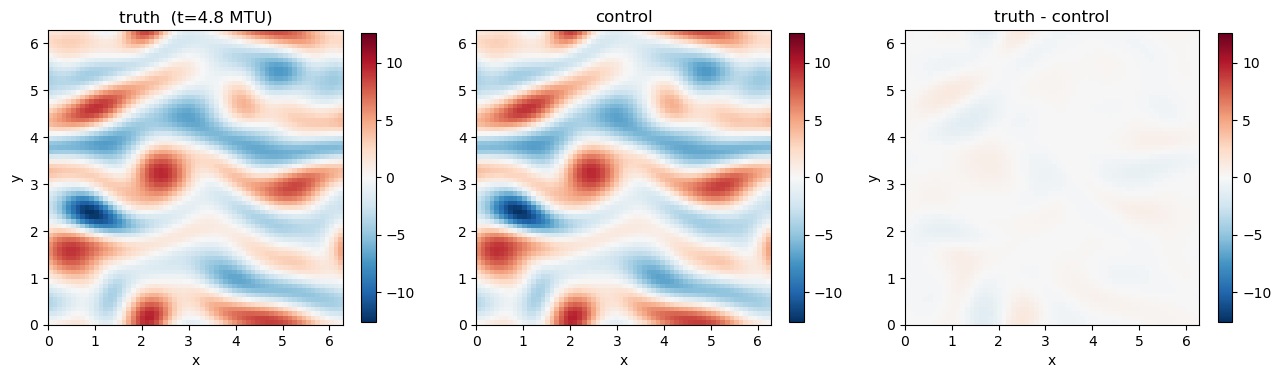

Snapshot at time = 10.0 MTU  (~8.3 days)  ->  index 33 of 2401


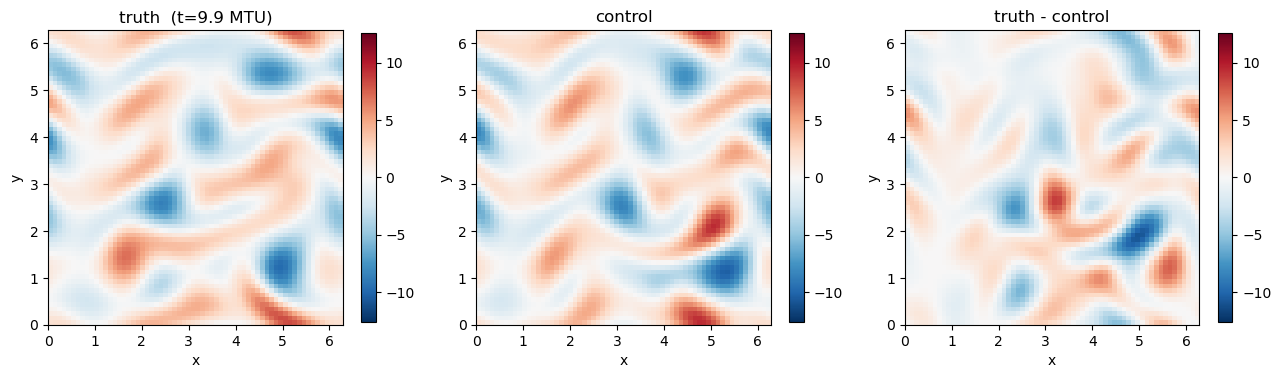

Snapshot at time = 20.0 MTU  (~16.7 days)  ->  index 66 of 2401


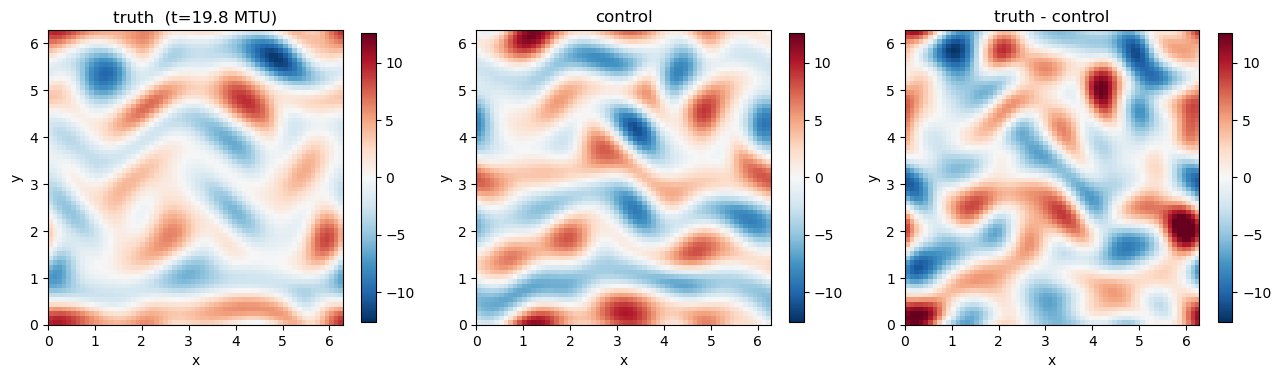

Snapshot at time = 30.0 MTU  (~25.0 days)  ->  index 100 of 2401


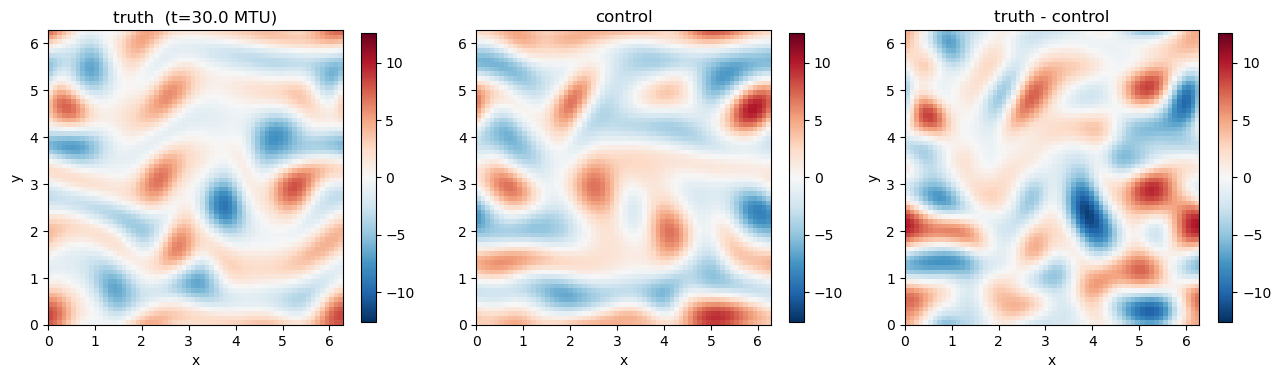

In [6]:
times_mtu = [5, 10, 20, 30]
ti = [int(time_mtu / DT_OBS) for time_mtu in times_mtu]
qt = [truth["q"].isel(time=ti_).values for ti_ in ti]
qc = [control["q"].isel(time=ti_).values for ti_ in ti]
v  = np.abs(qt).max()

for time_mtu, ti, qt_, qc_ in zip(times_mtu, ti, qt, qc):
    print(f"Snapshot at time = {time_mtu:.1f} MTU  (~{time_mtu/1.2:.1f} days)  ->  index {ti} of {len(times)}")
    fig, ax = plt.subplots(1, 3, figsize=(13, 4))
    show(ax[0], qt_, L, vsym=v, title=f"truth  (t={times[ti]:.1f} MTU)")
    show(ax[1], qc_, L, vsym=v, title="control")
    show(ax[2], qt_ - qc_, L, vsym=v, title="truth - control")
    for a in ax:
        fig.colorbar(a.images[0], ax=a, shrink=0.8)
    fig.tight_layout(); plt.show()

## 2. Sample observations (100 % and 25 %)

Observations are the truth plus zero-mean Gaussian noise
($\sigma_\text{obs}=10\%$ of climatology), taken at every observation time.
The **full** network observes every grid point; the **sparse** network observes
a fixed random 25 % of points (the same mask at all times). Unobserved points
are stored as `NaN`; the boolean coverage mask is stored alongside.

In [7]:
rng = np.random.default_rng(seed)
qtruth = truth["q"].values                  # (T, N, N)
N = PARAMS["N"]

# fixed masks
mask_full = np.ones((N, N), dtype=bool)
k = int(round(SPARSE_FRAC * N * N))
sel = rng.choice(N * N, size=k, replace=False)
mask_sparse = np.zeros(N * N, dtype=bool); mask_sparse[sel] = True
mask_sparse = mask_sparse.reshape(N, N)

def sample_and_store(mask, coverage, path):
    noise = rng.normal(0.0, sigma_obs, size=qtruth.shape)
    obs = qtruth + noise
    obs = np.where(mask[None, :, :], obs, np.nan)          # blank unobserved
    ds = xr.Dataset(
        {"obs":  (("time", "y", "x"), obs.astype(np.float64)),
         "mask": (("y", "x"), mask.astype(np.int8))},
        coords={"time": times, "y": truth["y"].values, "x": truth["x"].values},
        attrs={**truth.attrs, "sigma_obs": sigma_obs, "dt_obs": DT_OBS,
               "coverage": coverage, "source": "truth"},
    )
    _save_netcdf(ds, path)
    return ds

obs_full   = sample_and_store(mask_full,   1.0,         "da_data/obs_full.nc")
obs_sparse = sample_and_store(mask_sparse, SPARSE_FRAC, "da_data/obs_sparse.nc")

print("full   coverage:", np.isfinite(obs_full["obs"].isel(time=0)).mean().item())
print("sparse coverage:", np.isfinite(obs_sparse["obs"].isel(time=0)).mean().item())

full   coverage: 1.0
sparse coverage: 0.25


## Check 3 — coverage maps and an observed field

The sparse mask, and the truth field seen through it (with noise). Data
assimilation only ever sees the right-hand panel.

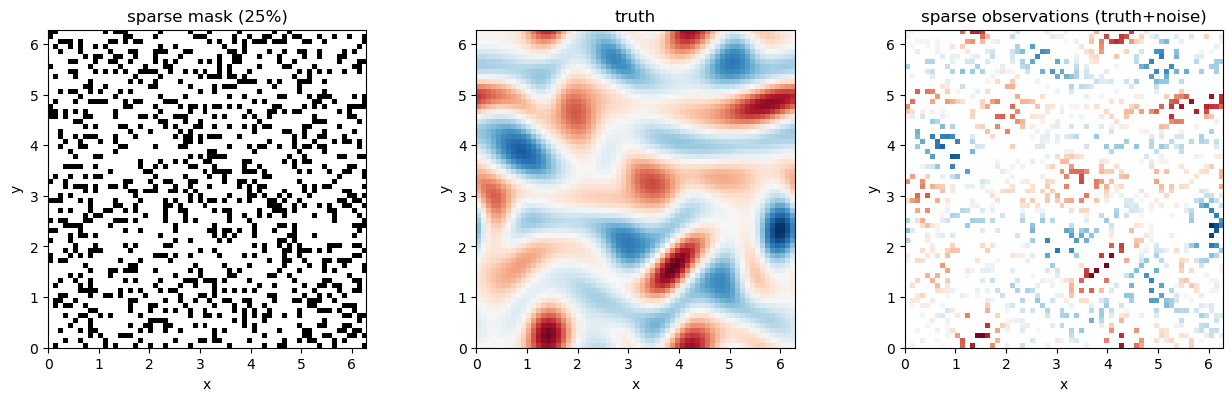

In [8]:
ti = len(times) // 2
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(mask_sparse.T, origin="lower", extent=[0, L, 0, L], cmap="Greys")
ax[0].set_title(f"sparse mask ({SPARSE_FRAC:.0%})"); ax[0].set_xlabel("x"); ax[0].set_ylabel("y")
v = np.abs(truth["q"].isel(time=ti).values).max()
show(ax[1], truth["q"].isel(time=ti).values, L, vsym=v, title="truth")
show(ax[2], obs_sparse["obs"].isel(time=ti).values, L, vsym=v,
     title="sparse observations (truth+noise)")
fig.tight_layout(); plt.show()

## Sanity 4 — observation error statistics

The observation increments $o - q_\text{truth}$ at observed points should be
zero-mean Gaussian with standard deviation $\sigma_\text{obs}$.

residual mean = -0.0002  (target 0)
residual std  = 0.3285   (target sigma_obs = 0.3284)


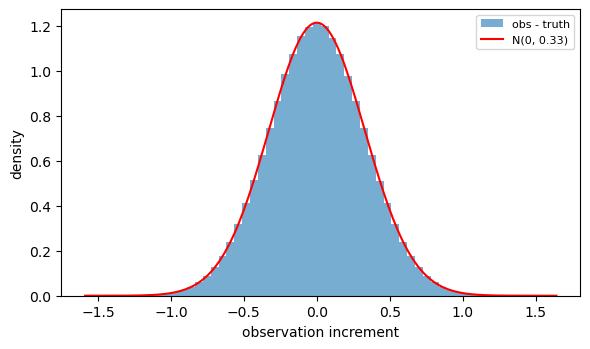

In [9]:
resid = (obs_sparse["obs"].values - qtruth)
resid = resid[np.isfinite(resid)]
print(f"residual mean = {resid.mean():+.4f}  (target 0)")
print(f"residual std  = {resid.std():.4f}   (target sigma_obs = {sigma_obs:.4f})")

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.hist(resid, bins=60, density=True, alpha=0.6, label="obs - truth")
xx = np.linspace(resid.min(), resid.max(), 200)
ax.plot(xx, np.exp(-xx**2/(2*sigma_obs**2))/(sigma_obs*np.sqrt(2*np.pi)),
        "r-", label=f"N(0, {sigma_obs:.2f})")
ax.set_xlabel("observation increment"); ax.set_ylabel("density")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## Sanity 5 — climatological consistency

Truth and control are different realisations of the *same* turbulence, so their
time-mean energy spectra should coincide even though the instantaneous fields
differ. If they overlap, both runs sit on the same attractor — the twin setup is
sound.

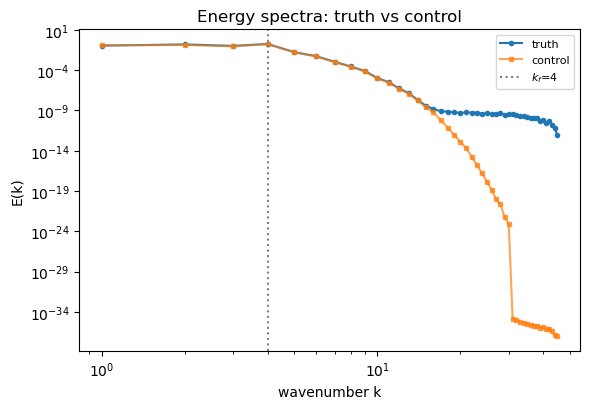

In [11]:
k_t, E_t = kinetic_energy_spectrum(truth)
k_c, E_c = kinetic_energy_spectrum(control)

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.loglog(k_t, E_t, "o-", ms=3, label="truth")
ax.loglog(k_c, E_c, "s-", ms=3, label="control", alpha=0.7)
ax.axvline(PARAMS["k_f"], color="gray", ls=":", label=f"$k_f$={PARAMS['k_f']}")
ax.set_xlabel("wavenumber k"); ax.set_ylabel("E(k)")
ax.set_title("Energy spectra: truth vs control"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## Stored files & next steps

Written under `da_data/`:

| file | contents |
|------|----------|
| `control.nc` | undisturbed trajectory (assimilation target/background) |
| `truth.nc`   | disturbed trajectory (reference truth) |
| `obs_full.nc`   | 100 % observations (truth + noise), with `mask` |
| `obs_sparse.nc` | 25 % observations (truth + noise), with `mask` |

Each observation file carries `sigma_obs`, `dt_obs`, and `coverage` in its
attributes. **Next:** run an EnKF from the control initial state, assimilating
`obs_full` / `obs_sparse` every `dt_obs`, and compare the analysis RMSE against
this free-running control divergence as the baseline to beat.